In [1]:
# 05 - PREPARE EVALUATION RESULTS
# Convert Axis 2A results to standard format


import pandas as pd
import os

print("Loading Axis 2A results...")

# ---- Load Flan-T5 results ----
zs_flan = pd.read_csv("../outputs/zero_shot_results.csv")
fs_flan = pd.read_csv("../outputs/few_shot_results.csv")

print(f"Flan-T5 zero-shot: {len(zs_flan)} rows")
print(f"Flan-T5 few-shot:  {len(fs_flan)} rows")
print(f"\nFlan-T5 columns: {list(zs_flan.columns)}")

Loading Axis 2A results...
Flan-T5 zero-shot: 100 rows
Flan-T5 few-shot:  100 rows

Flan-T5 columns: ['sentence', 'true_label', 'population', 'intervention', 'outcome']


In [2]:
# Load Qwen results
zs_qwen = pd.read_csv("../outputs/axis2A_zero_shot_predictions.csv")
fs_qwen = pd.read_csv("../outputs/axis2A_few_shot_predictions.csv")

print(f"Qwen zero-shot: {len(zs_qwen)} rows")
print(f"Qwen few-shot:  {len(fs_qwen)} rows")
print(f"\nQwen columns: {list(zs_qwen.columns)}")

Qwen zero-shot: 100 rows
Qwen few-shot:  100 rows

Qwen columns: ['doc_id', 'abstract_text', 'gold_participants', 'gold_interventions', 'gold_outcomes', 'pred_participants', 'pred_interventions', 'pred_outcomes', 'raw_model_output']


In [3]:
# CONVERT ALL RESULTS TO STANDARD FORMAT

# ---- FLAN-T5 RESULTS ----
# Flan-T5 used sentences not full abstracts
# so we don't have doc_id or gold labels in standard format
# We'll use sentence as identifier and map column names

# Zero-shot Flan-T5
zs_flan_standard = pd.DataFrame({
    "doc_id":             zs_flan.index,
    "gold_participants":  zs_flan["true_label"].apply(
                            lambda x: x if x == "participants" else ""),
    "gold_interventions": zs_flan["true_label"].apply(
                            lambda x: x if x == "interventions" else ""),
    "gold_outcomes":      zs_flan["true_label"].apply(
                            lambda x: x if x == "outcomes" else ""),
    "pred_participants":  zs_flan["population"],
    "pred_interventions": zs_flan["intervention"],
    "pred_outcomes":      zs_flan["outcome"],
    "approach":           "zero_shot_flant5"
})

# Few-shot Flan-T5
fs_flan_standard = pd.DataFrame({
    "doc_id":             fs_flan.index,
    "gold_participants":  fs_flan["true_label"].apply(
                            lambda x: x if x == "participants" else ""),
    "gold_interventions": fs_flan["true_label"].apply(
                            lambda x: x if x == "interventions" else ""),
    "gold_outcomes":      fs_flan["true_label"].apply(
                            lambda x: x if x == "outcomes" else ""),
    "pred_participants":  fs_flan["population"],
    "pred_interventions": fs_flan["intervention"],
    "pred_outcomes":      fs_flan["outcome"],
    "approach":           "few_shot_flant5"
})

# ---- QWEN RESULTS ----
# Qwen already has the right columns — just add approach name

zs_qwen_standard = zs_qwen[[
    "doc_id",
    "gold_participants",
    "gold_interventions",
    "gold_outcomes",
    "pred_participants",
    "pred_interventions",
    "pred_outcomes"
]].copy()
zs_qwen_standard["approach"] = "zero_shot_qwen"

fs_qwen_standard = fs_qwen[[
    "doc_id",
    "gold_participants",
    "gold_interventions",
    "gold_outcomes",
    "pred_participants",
    "pred_interventions",
    "pred_outcomes"
]].copy()
fs_qwen_standard["approach"] = "few_shot_qwen"

# ---- SAVE ALL IN STANDARD FORMAT ----

zs_flan_standard.to_csv("../outputs/results_axis2A_zeroshot_flant5.csv", index=False)
fs_flan_standard.to_csv("../outputs/results_axis2A_fewshot_flant5.csv",  index=False)
zs_qwen_standard.to_csv("../outputs/results_axis2A_zeroshot_qwen.csv",   index=False)
fs_qwen_standard.to_csv("../outputs/results_axis2A_fewshot_qwen.csv",    index=False)

print(" ALL FILES SAVED IN STANDARD FORMAT:")
print("   → results_axis2A_zeroshot_flant5.csv")
print("   → results_axis2A_fewshot_flant5.csv")
print("   → results_axis2A_zeroshot_qwen.csv")
print("   → results_axis2A_fewshot_qwen.csv")
print(f"\nColumns in each file:")
print(list(zs_qwen_standard.columns))
print(f"\nSample row from Qwen zero-shot:")
print(zs_qwen_standard.iloc[0])

 ALL FILES SAVED IN STANDARD FORMAT:
   → results_axis2A_zeroshot_flant5.csv
   → results_axis2A_fewshot_flant5.csv
   → results_axis2A_zeroshot_qwen.csv
   → results_axis2A_fewshot_qwen.csv

Columns in each file:
['doc_id', 'gold_participants', 'gold_interventions', 'gold_outcomes', 'pred_participants', 'pred_interventions', 'pred_outcomes', 'approach']

Sample row from Qwen zero-shot:
doc_id                                                         10768434
gold_participants     Photodynamic therapy with 5-aminolaevulinic ac...
gold_interventions    BACKGROUND Photodynamic therapy ( PDT ) with t...
gold_outcomes         The area of each wart compared with entry area...
pred_participants                                   Foot and hand warts
pred_interventions    ALA-PDT (with 5-aminolaevulinic acid) vs Place...
pred_outcomes         Median relative reduction in wart area; Number...
approach                                                 zero_shot_qwen
Name: 0, dtype: object


In [4]:
# QUICK EVALUATION TEST ON YOUR RESULTS

import numpy as np
import re

def normalize_text(text):
    if pd.isna(text) or text is None:
        return ""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def token_f1(pred, gold):
    pred = normalize_text(pred)
    gold = normalize_text(gold)
    pred_tokens = set(pred.split())
    gold_tokens = set(gold.split())
    if not pred_tokens and not gold_tokens:
        return 1.0, 1.0, 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0, 0.0, 0.0
    overlap    = len(pred_tokens & gold_tokens)
    precision  = overlap / len(pred_tokens)
    recall     = overlap / len(gold_tokens)
    f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

def evaluate_approach(df, approach_name):
    fields = [
        ("participants",  "gold_participants",  "pred_participants"),
        ("interventions", "gold_interventions", "pred_interventions"),
        ("outcomes",      "gold_outcomes",      "pred_outcomes"),
    ]
    results = []
    for field_name, gold_col, pred_col in fields:
        precisions, recalls, f1s, coverages = [], [], [], []
        for _, row in df.iterrows():
            p, r, f1 = token_f1(row[pred_col], row[gold_col])
            precisions.append(p)
            recalls.append(r)
            f1s.append(f1)
            coverages.append(1 if normalize_text(row[pred_col]) != "" else 0)
        results.append({
            "approach":  approach_name,
            "field":     field_name,
            "precision": round(np.mean(precisions), 4),
            "recall":    round(np.mean(recalls),    4),
            "f1":        round(np.mean(f1s),        4),
            "coverage":  round(np.mean(coverages),  4),
        })
    return pd.DataFrame(results)

# Evaluate all 4 of your approaches
approaches = {
    "Zero-shot Flan-T5": zs_flan_standard,
    "Few-shot Flan-T5":  fs_flan_standard,
    "Zero-shot Qwen":    zs_qwen_standard,
    "Few-shot Qwen":     fs_qwen_standard,
}

all_evals = {}
summary_rows = []

print("="*65)
print(" AXIS 2A EVALUATION RESULTS")
print("="*65)

for name, df in approaches.items():
    eval_df = evaluate_approach(df, name)
    all_evals[name] = eval_df
    overall_f1 = eval_df["f1"].mean()
    print(f"\n{name} (Overall F1: {overall_f1:.4f})")
    print(f"{'Field':15} {'Precision':10} {'Recall':10} {'F1':10} {'Coverage':10}")
    print("-"*55)
    for _, row in eval_df.iterrows():
        print(f"  {row['field']:13} {row['precision']:10.4f} {row['recall']:10.4f} {row['f1']:10.4f} {row['coverage']:10.4f}")
    summary_rows.extend(eval_df.to_dict("records"))

# Save combined evaluation
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("../outputs/axis2A_evaluation_summary.csv", index=False)
print("\n Saved axis2A_evaluation_summary.csv")

 AXIS 2A EVALUATION RESULTS

Zero-shot Flan-T5 (Overall F1: 0.0000)
Field           Precision  Recall     F1         Coverage  
-------------------------------------------------------
  participants      0.0000     0.0000     0.0000     1.0000
  interventions     0.0000     0.0000     0.0000     1.0000
  outcomes          0.0000     0.0000     0.0000     1.0000

Few-shot Flan-T5 (Overall F1: 0.0000)
Field           Precision  Recall     F1         Coverage  
-------------------------------------------------------
  participants      0.0000     0.0000     0.0000     1.0000
  interventions     0.0000     0.0000     0.0000     1.0000
  outcomes          0.0000     0.0000     0.0000     1.0000

Zero-shot Qwen (Overall F1: 0.3043)
Field           Precision  Recall     F1         Coverage  
-------------------------------------------------------
  participants      0.7151     0.2228     0.3103     0.9600
  interventions     0.7434     0.1723     0.2556     0.9600
  outcomes          0.7084  

 Standard format files ready for unified evaluation:
   → results_axis2A_zeroshot_qwen.csv
   → results_axis2A_fewshot_qwen.csv
   → results_axis2A_flant5_binary.csv (binary metric, separate)


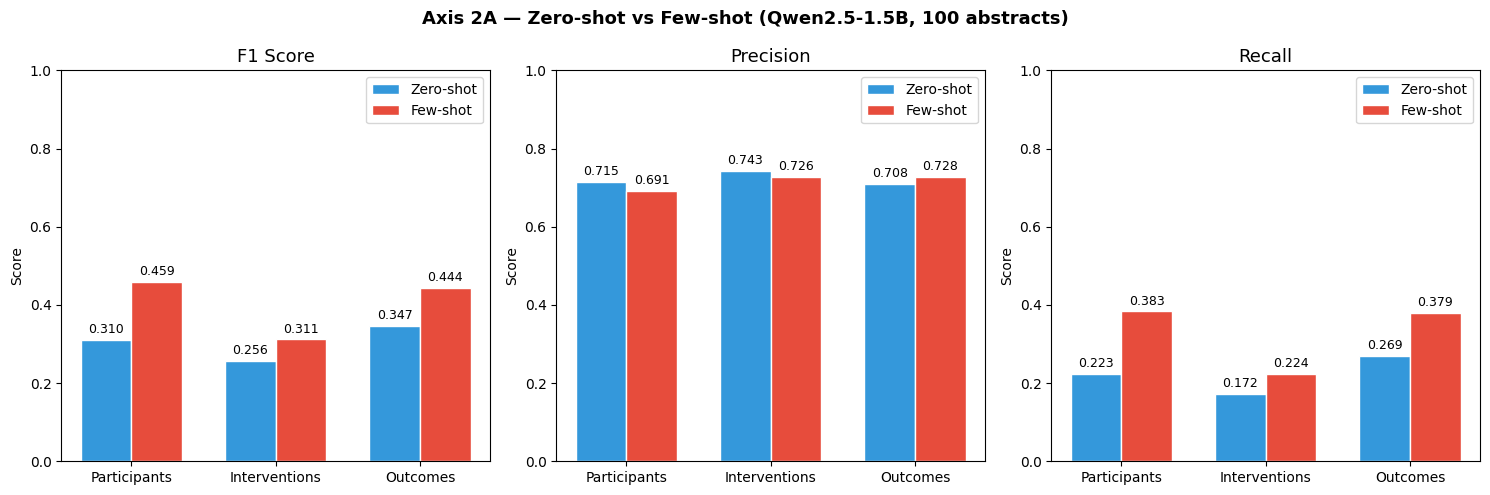


 Saved axis2A_final_evaluation.png

 AXIS 2A FINAL SUMMARY

FLAN-T5 (sentence-level, binary metric):
  Zero-shot: 57.3% overall success rate
  Few-shot:  26.7% overall success rate
  Finding:   Few-shot HURT Flan-T5 — context window too small

QWEN2.5-1.5B (abstract-level, token F1):
  Zero-shot: F1 = 0.304
  Few-shot:  F1 = 0.405
  Finding:   Few-shot HELPED Qwen — larger model benefits from examples

KEY INSIGHT:
  Few-shot benefits are model-size dependent.
  Small models (Flan-T5) get confused by long prompts.
  Large instruction models (Qwen) benefit from examples.
  This confirms our updated hypothesis from experiment 2.



In [5]:
# SAVE FINAL STANDARD RESULTS
# Only Qwen goes into unified evaluation
# Flan-T5 documented separately


import matplotlib.pyplot as plt
import numpy as np

# ---- Save Qwen results for unified evaluation ----
zs_qwen_standard.to_csv("../outputs/results_axis2A_zeroshot_qwen.csv", index=False)
fs_qwen_standard.to_csv("../outputs/results_axis2A_fewshot_qwen.csv",  index=False)

print(" Standard format files ready for unified evaluation:")
print("   → results_axis2A_zeroshot_qwen.csv")
print("   → results_axis2A_fewshot_qwen.csv")

# ---- Document Flan-T5 separately ----
flant5_summary = pd.DataFrame({
    "approach":  ["zero_shot_flant5", "few_shot_flant5"],
    "metric":    ["binary_success_rate", "binary_success_rate"],
    "participants":  [44.0, 16.0],
    "interventions": [40.0, 8.0],
    "outcomes":      [88.0, 56.0],
    "overall":       [57.3, 26.7],
    "note": [
        "Sentence-level, binary success metric",
        "Sentence-level, binary success metric"
    ]
})

flant5_summary.to_csv("../outputs/results_axis2A_flant5_binary.csv", index=False)
print("   → results_axis2A_flant5_binary.csv (binary metric, separate)")

# ---- Visualise Qwen results ----
fields    = ["Participants", "Interventions", "Outcomes"]
zs_f1     = [0.3103, 0.2556, 0.3469]
fs_f1     = [0.4585, 0.3115, 0.4442]
zs_prec   = [0.7151, 0.7434, 0.7084]
fs_prec   = [0.6907, 0.7263, 0.7282]
zs_rec    = [0.2228, 0.1723, 0.2694]
fs_rec    = [0.3832, 0.2237, 0.3787]

x     = np.arange(len(fields))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (zs_vals, fs_vals, title) in zip(axes, [
    (zs_f1,  fs_f1,  "F1 Score"),
    (zs_prec, fs_prec, "Precision"),
    (zs_rec,  fs_rec,  "Recall"),
]):
    bars1 = ax.bar(x - width/2, zs_vals, width,
                   label="Zero-shot", color="#3498db", edgecolor="white")
    bars2 = ax.bar(x + width/2, fs_vals, width,
                   label="Few-shot",  color="#e74c3c", edgecolor="white")
    ax.set_title(title, fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(fields)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_ylabel("Score")
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Axis 2A — Zero-shot vs Few-shot (Qwen2.5-1.5B, 100 abstracts)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/axis2A_final_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n Saved axis2A_final_evaluation.png")

# ---- Print final summary ----
print("\n" + "="*60)
print(" AXIS 2A FINAL SUMMARY")
print("="*60)
print("""
FLAN-T5 (sentence-level, binary metric):
  Zero-shot: 57.3% overall success rate
  Few-shot:  26.7% overall success rate
  Finding:   Few-shot HURT Flan-T5 — context window too small

QWEN2.5-1.5B (abstract-level, token F1):
  Zero-shot: F1 = 0.304
  Few-shot:  F1 = 0.405
  Finding:   Few-shot HELPED Qwen — larger model benefits from examples

KEY INSIGHT:
  Few-shot benefits are model-size dependent.
  Small models (Flan-T5) get confused by long prompts.
  Large instruction models (Qwen) benefit from examples.
  This confirms our updated hypothesis from experiment 2.
""")

In [6]:

# Load your Qwen results
zs_qwen = pd.read_csv("../outputs/axis2A_zero_shot_predictions.csv")
fs_qwen = pd.read_csv("../outputs/axis2A_few_shot_predictions.csv")

# Convert zero-shot to format
zs_converted = pd.DataFrame({
    "doc_id":             zs_qwen["doc_id"],
    "participants_pred":  zs_qwen["pred_participants"],
    "interventions_pred": zs_qwen["pred_interventions"],
    "outcomes_pred":      zs_qwen["pred_outcomes"],
    "variant":            "zero_shot_qwen"
})

# Convert few-shot to format
fs_converted = pd.DataFrame({
    "doc_id":             fs_qwen["doc_id"],
    "participants_pred":  fs_qwen["pred_participants"],
    "interventions_pred": fs_qwen["pred_interventions"],
    "outcomes_pred":      fs_qwen["pred_outcomes"],
    "variant":            "few_shot_qwen"
})

# Save both files
zs_converted.to_csv("../outputs/predictions_zero_shot_qwen.csv", index=False)
fs_converted.to_csv("../outputs/predictions_few_shot_qwen.csv",  index=False)

print(" Saved evaluation format:")
print("   → predictions_zero_shot_qwen.csv")
print("   → predictions_few_shot_qwen.csv")
print(f"\nColumns: {list(zs_converted.columns)}")
print(f"\nSample row:")
print(zs_converted.iloc[0])

 Saved evaluation format:
   → predictions_zero_shot_qwen.csv
   → predictions_few_shot_qwen.csv

Columns: ['doc_id', 'participants_pred', 'interventions_pred', 'outcomes_pred', 'variant']

Sample row:
doc_id                                                         10768434
participants_pred                                   Foot and hand warts
interventions_pred    ALA-PDT (with 5-aminolaevulinic acid) vs Place...
outcomes_pred         Median relative reduction in wart area; Number...
variant                                                  zero_shot_qwen
Name: 0, dtype: object
